# FFT plot

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import warnings


def fftPlot(sig, dt=None, plot=True):
    # Here it's assumes analytic signal (real signal...) - so only half of the axis is required

    if dt is None:
        dt = 1
        t = np.arange(0, sig.shape[-1])
        xLabel = 'samples'
    else:
        t = np.arange(0, sig.shape[-1]) * dt
        xLabel = 'freq [Hz]'

    if sig.shape[0] % 2 != 0:
        warnings.warn("signal preferred to be even in size, autoFixing it...")
        t = t[0:-1]
        sig = sig[0:-1]

    sigFFT = np.fft.fft(sig) / t.shape[0]  # Divided by size t for coherent magnitude

    freq = np.fft.fftfreq(t.shape[0], d=dt)

    # Plot analytic signal - right half of frequence axis needed only...
    firstNegInd = np.argmax(freq < 0)
    freqAxisPos = freq[0:firstNegInd]
    sigFFTPos = 2 * sigFFT[0:firstNegInd]  # *2 because of magnitude of analytic signal

    if plot:
        plt.figure()
        plt.plot(freqAxisPos, np.abs(sigFFTPos))
        plt.xlabel(xLabel)
        plt.ylabel('mag')
        plt.title('Analytic FFT plot')
        plt.show()

    # return sigFFTPos, freqAxisPos

/tmp/ipykernel_152559/1477883824.py:18: UserWarning: signal preferred to be even in size, autoFixing it...
  warnings.warn("signal preferred to be even in size, autoFixing it...")


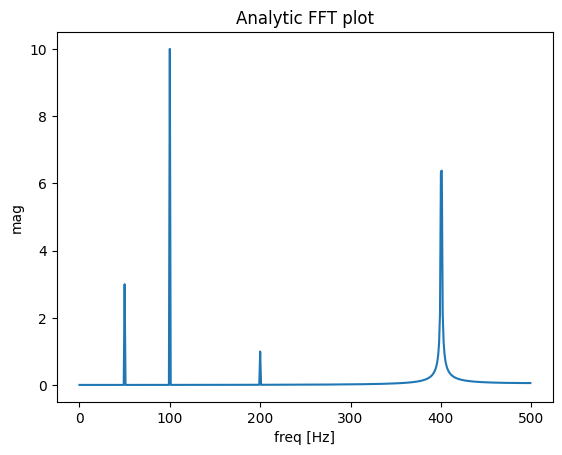

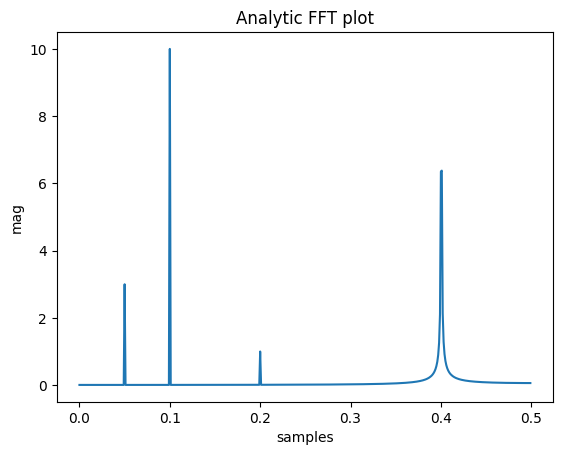

In [4]:
dt = 1 / 1000

# Build a signal within Nyquist - the result will be the positive FFT with actual magnitude
f0 = 200  # [Hz]
t = np.arange(0, 1 + dt, dt)
sig = (
    1 * np.sin(2 * np.pi * f0 * t)
    + 10 * np.sin(2 * np.pi * f0 / 2 * t)
    + 3 * np.sin(2 * np.pi * f0 / 4 * t)
    + 10 * np.sin(2 * np.pi * (f0 * 2 + 0.5) * t)  # <--- not sampled on grid so the peak will not be actual height
)
# Result in frequencies
fftPlot(sig, dt=dt)
# Result in samples (if the frequencies axis is unknown)
fftPlot(sig)

In [7]:
import scipy.io.wavfile as wavfile
import scipy
import scipy.fftpack


Frequency sampling 22050
Channels 1
Complete Samplings N 241316
secs 10.94403628117914
Timestep between samples Ts 4.5351473922902495e-05


TypeError: 'module' object is not callable

In [ ]:
fs_rate, signal = wavfile.read("../data/sound/count_to_10_mono_22050.wav")
fft_out = scipy.fftpack.fft(signal)
plt.plot(signal, np.abs(fft_out))
plt.show()

In [ ]:

fs_rate, signal = wavfile.read("../data/sound/count_to_10_mono_22050.wav")
print("Frequency sampling", fs_rate)
l_audio = len(signal.shape)
print("Channels", l_audio)
if l_audio == 2:
    signal = signal.sum(axis=1) / 2
N = signal.shape[0]
print("Complete Samplings N", N)
secs = N / float(fs_rate)
print("secs", secs)
Ts = 1.0/fs_rate # sampling interval in time
print("Timestep between samples Ts", Ts)
t = np.arange(0, secs, Ts) # time vector as scipy arange field / numpy.ndarray
FFT = np.abs(scipy.fft(signal))
FFT_side = FFT[range(N/2)] # one side FFT range
freqs = scipy.fftpack.fftfreq(signal.size, t[1]-t[0])
fft_freqs = np.array(freqs)
freqs_side = freqs[range(N/2)] # one side frequency range
fft_freqs_side = np.array(freqs_side)
plt.subplot(311)
p1 = plt.plot(t, signal, "g") # plotting the signal
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.subplot(312)
p2 = plt.plot(freqs, FFT, "r") # plotting the complete fft spectrum
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count dbl-sided')
plt.subplot(313)
p3 = plt.plot(freqs_side, abs(FFT_side), "b") # plotting the positive fft spectrum
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count single-sided')
plt.show()